# Task 1 — Custom Dataset Fine-Tuning of a Text-to-Image Model

## Objective

Use a custom image-caption dataset to refine a pretrained Stable Diffusion text-to-image model using Low-Rank Adaptation (LoRA).

The goal is to adapt the pretrained model toward the visual concepts and natural-language descriptions represented in the custom Flickr8k image-caption dataset.

## Method

This experiment uses Stable Diffusion v1.5 as the pretrained text-to-image model and LoRA as the parameter-efficient fine-tuning method.

The notebook demonstrates:

1. Loading a custom image-caption dataset
2. Inspecting and preprocessing training examples
3. Loading the pretrained Stable Diffusion model
4. Generating baseline images before fine-tuning
5. Configuring LoRA adapters
6. Performing actual fine-tuning with loss calculation and optimizer updates
7. Recording training loss
8. Saving the trained LoRA weights
9. Reloading the trained LoRA weights
10. Generating images using the refined model
11. Comparing baseline and refined outputs
12. Documenting results and limitations

In [ ]:
# ============================================================
# TASK 1 — ENVIRONMENT VERIFICATION
# ============================================================

print("===== ENVIRONMENT VERIFICATION =====")

import sys
import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)

print("\n===== GPU =====")
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

print("\n===== REQUIRED LIBRARIES =====")

import diffusers
import transformers
import accelerate
import peft
import datasets
import safetensors

print("Diffusers:", diffusers.__version__)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("PEFT:", peft.__version__)
print("Datasets:", datasets.__version__)
print("Safetensors:", safetensors.__version__)

print("\n===== VERIFICATION =====")

assert torch.cuda.is_available(), "CUDA GPU is not available."

print("PASS - Environment is ready for Task 1.")

===== ENVIRONMENT VERIFICATION =====
Python: 3.13.15
PyTorch: 2.14.0+cu130

===== GPU =====
CUDA available: True
GPU: Tesla T4
CUDA version: 13.0

===== REQUIRED LIBRARIES =====
Diffusers: 0.40.0
Transformers: 5.17.0
Accelerate: 1.15.0
PEFT: 0.21.1
Datasets: 5.0.1
Safetensors: 0.8.0

===== VERIFICATION =====
PASS - Environment is ready for Task 1.


In [ ]:
# ============================================================
#  LOAD CUSTOM IMAGE-CAPTION DATASET
# ============================================================

from datasets import load_dataset

print("===== LOADING CUSTOM DATASET =====")

dataset = load_dataset(
    "intro/flickr8k",
    split="train",
    streaming=True
)

print("\nDataset loaded successfully.")
print("Dataset type:", type(dataset))
print("Dataset features:")

for name, feature in dataset.features.items():
    print(f"  {name}: {feature}")

print("\nPASS - Custom image-caption dataset loaded.")

===== LOADING CUSTOM DATASET =====


Resolving data files:   0%|          | 0/6001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/6001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]


Dataset loaded successfully.
Dataset type: <class 'datasets.iterable_dataset.IterableDataset'>
Dataset features:
  image: Image(mode=None, decode=True)
  split: Value('string')
  caption_0: Value('string')
  caption_1: Value('string')
  caption_2: Value('string')
  caption_3: Value('string')
  caption_4: Value('string')

PASS - Custom image-caption dataset loaded.


In [ ]:
# ============================================================
# INSPECT A REAL TRAINING EXAMPLE
# ============================================================

print("===== INSPECTING CUSTOM TRAINING EXAMPLE =====")

sample = next(iter(dataset))

image = sample["image"]

print("\n===== IMAGE =====")
print("Image type:", type(image))
print("Image size:", image.size)
print("Image mode:", image.mode)

print("\n===== CAPTIONS =====")

for i in range(5):
    print(f"Caption {i + 1}: {sample[f'caption_{i}']}")

print("\n===== SELECTED TRAINING CAPTION =====")
print(sample["caption_0"])

print("\nPASS - A real image-caption training example was inspected.")

===== INSPECTING CUSTOM TRAINING EXAMPLE =====

===== IMAGE =====
Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (375, 500)
Image mode: RGB

===== CAPTIONS =====
Caption 1: A child in a pink dress is climbing up a set of stairs in an entry way .
Caption 2: A girl going into a wooden building .
Caption 3: A little girl climbing into a wooden playhouse .
Caption 4: A little girl climbing the stairs to her playhouse .
Caption 5: A little girl in a pink dress going into a wooden cabin .

===== SELECTED TRAINING CAPTION =====
A child in a pink dress is climbing up a set of stairs in an entry way .

PASS - A real image-caption training example was inspected.


In [ ]:
# ============================================================
# PREPARE TRAINING DATA
# ============================================================

from PIL import Image
import torch

print("===== PREPARING TRAINING DATA =====")

# Number of training examples to prepare
NUM_SAMPLES = 60

images = []
captions = []

stream = iter(dataset)

for _ in range(NUM_SAMPLES):
    sample = next(stream)

    image = sample["image"].convert("RGB")
    caption = sample["caption_0"].strip()

    images.append(image)
    captions.append(caption)

print("Number of images:", len(images))
print("Number of captions:", len(captions))

print("\n===== FIRST TRAINING EXAMPLE =====")
print("Image size:", images[0].size)
print("Image mode:", images[0].mode)
print("Caption:", captions[0])

assert len(images) == NUM_SAMPLES
assert len(captions) == NUM_SAMPLES
assert all(isinstance(image, Image.Image) for image in images)
assert all(isinstance(caption, str) and len(caption) > 0 for caption in captions)

print("\nPASS - Training images and captions prepared successfully.")

===== PREPARING TRAINING DATA =====
Number of images: 60
Number of captions: 60

===== FIRST TRAINING EXAMPLE =====
Image size: (375, 500)
Image mode: RGB
Caption: A child in a pink dress is climbing up a set of stairs in an entry way .

PASS - Training images and captions prepared successfully.


In [ ]:
# ============================================================
# LOAD THE PRETRAINED MODEL
# ============================================================

import torch
from diffusers import StableDiffusionPipeline

print("===== LOADING PRETRAINED STABLE DIFFUSION =====")

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print("Model:", MODEL_ID)
print("Device:", device)
print("Data type:", dtype)

pipeline = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype
)

pipeline = pipeline.to(device)

print("\nModel loaded successfully.")
print("Pipeline type:", type(pipeline))
print("\nPASS - Pretrained Stable Diffusion model is ready.")

===== LOADING PRETRAINED STABLE DIFFUSION =====
Model: stable-diffusion-v1-5/stable-diffusion-v1-5
Device: cuda
Data type: torch.float16


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]


Model loaded successfully.
Pipeline type: <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'>

PASS - Pretrained Stable Diffusion model is ready.


===== GENERATING BASELINE IMAGES =====
Generating baseline image 1/3...


  0%|          | 0/20 [00:00<?, ?it/s]

Generating baseline image 2/3...


  0%|          | 0/20 [00:00<?, ?it/s]

Generating baseline image 3/3...


  0%|          | 0/20 [00:00<?, ?it/s]


===== BASELINE RESULTS =====

Baseline 0 prompt:
A child in a pink dress is climbing up a set of stairs in an entry way .

Baseline 1 prompt:
A black dog and a spotted dog are fighting

Baseline 2 prompt:
A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .


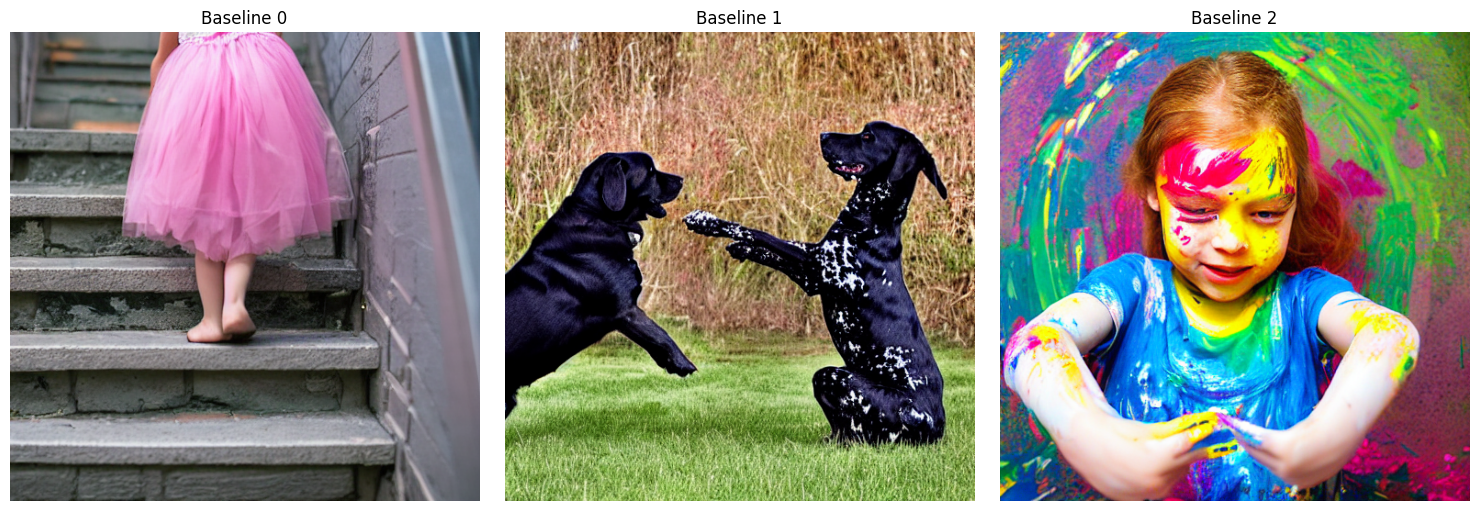


PASS - Baseline images generated and saved.


In [ ]:
# ============================================================
# GENERATE BASELINE IMAGES
# ============================================================

import os
import matplotlib.pyplot as plt

print("===== GENERATING BASELINE IMAGES =====")

os.makedirs("outputs/task1/baseline", exist_ok=True)

baseline_images = []
baseline_captions = captions[:3]

for i, prompt in enumerate(baseline_captions, start=1):
    print(f"Generating baseline image {i}/3...")

    result = pipeline(
        prompt,
        num_inference_steps=20,
        guidance_scale=7.5
    )

    image = result.images[0]
    baseline_images.append(image)

    image.save(
        f"outputs/task1/baseline/baseline_{i}.png"
    )

print("\n===== BASELINE RESULTS =====")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (image, prompt) in enumerate(
    zip(baseline_images, baseline_captions)
):
    axes[i].imshow(image)
    axes[i].set_title(f"Baseline {i}")
    axes[i].axis("off")
    print(f"\nBaseline {i} prompt:")
    print(prompt)

plt.tight_layout()
plt.show()

print("\nPASS - Baseline images generated and saved.")

In [ ]:
# ============================================================
# RELOAD THE CUSTOM DATASET
# ============================================================

from datasets import load_dataset

print("===== RELOADING CUSTOM DATASET =====")

dataset = load_dataset(
    "intro/flickr8k",
    split="train",
    streaming=True
)

print("Dataset type:", type(dataset))
print("Dataset features:", dataset.features)

print("\nPASS - Custom dataset reloaded successfully.")

===== RELOADING CUSTOM DATASET =====


Resolving data files:   0%|          | 0/6001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/6001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Dataset type: <class 'datasets.iterable_dataset.IterableDataset'>
Dataset features: {'image': Image(mode=None, decode=True), 'split': Value('string'), 'caption_0': Value('string'), 'caption_1': Value('string'), 'caption_2': Value('string'), 'caption_3': Value('string'), 'caption_4': Value('string')}

PASS - Custom dataset reloaded successfully.


In [ ]:
# ============================================================
# PREPARE THE FINE-TUNING DATA AND TRAINING COMPONENTS
# ============================================================

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("===== PREPARING FINE-TUNING =====")

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

IMAGE_SIZE = 256
BATCH_SIZE = 1
NUM_EPOCHS = 3
LEARNING_RATE = 1e-4
MAX_TEXT_LENGTH = 77

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)

# ------------------------------------------------------------
# Restore the 60 training examples after runtime restart
# ------------------------------------------------------------

print("\n===== LOADING TRAINING EXAMPLES =====")

training_images = []
training_captions = []

dataset_stream = iter(dataset)

for _ in range(60):
    sample = next(dataset_stream)

    training_images.append(
        sample["image"].convert("RGB")
    )

    training_captions.append(
        sample["caption_0"].strip()
    )

print("Training images:", len(training_images))
print("Training captions:", len(training_captions))

# ------------------------------------------------------------
# Image preprocessing
# ------------------------------------------------------------

image_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.BILINEAR
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])


class ImageCaptionDataset(Dataset):

    def __init__(self, images, captions):
        self.images = images
        self.captions = captions

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image = image_transform(self.images[index])

        caption = self.captions[index]

        tokens = pipeline.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LENGTH,
            return_tensors="pt"
        )

        return {
            "pixel_values": image,
            "input_ids": tokens.input_ids.squeeze(0)
        }


training_dataset = ImageCaptionDataset(
    training_images,
    training_captions
)

training_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# ------------------------------------------------------------
# Freeze components that are not being fine-tuned
# ------------------------------------------------------------

pipeline.vae.requires_grad_(False)
pipeline.text_encoder.requires_grad_(False)

pipeline.vae.eval()
pipeline.text_encoder.eval()

# Only LoRA parameters in the UNet are trainable.
pipeline.unet.train()

trainable_parameters = [
    parameter
    for parameter in pipeline.unet.parameters()
    if parameter.requires_grad
]

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=LEARNING_RATE
)

# Enable gradient checkpointing to reduce GPU memory usage.
pipeline.unet.enable_gradient_checkpointing()

print("\n===== TRAINING COMPONENTS =====")
print("Dataset size:", len(training_dataset))
print("Batches per epoch:", len(training_loader))
print("Trainable parameter tensors:", len(trainable_parameters))
print("Optimizer:", type(optimizer).__name__)

assert len(training_dataset) == 60
assert len(trainable_parameters) > 0

print("\nPASS - Fine-tuning components prepared.")
print("PASS - LoRA parameters connected to optimizer.")

===== PREPARING FINE-TUNING =====
Image size: 256
Batch size: 1
Epochs: 3
Learning rate: 0.0001

===== LOADING TRAINING EXAMPLES =====
Training images: 60
Training captions: 60

===== TRAINING COMPONENTS =====
Dataset size: 60
Batches per epoch: 60
Trainable parameter tensors: 256
Optimizer: AdamW

PASS - Fine-tuning components prepared.
PASS - LoRA parameters connected to optimizer.


In [ ]:
# ============================================================
# RESET LORA AND PREPARE STABLE FINE-TUNING
# ============================================================

import torch
import torch.nn.functional as F
from diffusers import StableDiffusionPipeline
from peft import LoraConfig

print("===== RESETTING LORA FOR STABLE FINE-TUNING =====")

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

# ------------------------------------------------------------
# Reload a fresh pretrained Stable Diffusion model
# ------------------------------------------------------------

pipeline = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype
).to(device)

# ------------------------------------------------------------
# Configure a fresh LoRA adapter
# ------------------------------------------------------------

pipeline.unet.requires_grad_(False)

lora_config = LoraConfig(
    r=4,
    lora_alpha=4,
    target_modules=[
        "to_q",
        "to_k",
        "to_v",
        "to_out.0"
    ],
    lora_dropout=0.0,
    bias="none"
)

pipeline.unet.add_adapter(
    lora_config,
    adapter_name="custom_dataset_adapter"
)

pipeline.unet.set_adapter(
    "custom_dataset_adapter"
)

# ------------------------------------------------------------
# Use FP32 for VAE encoding for numerical stability
# ------------------------------------------------------------

pipeline.vae.to(
    device=device,
    dtype=torch.float32
)

pipeline.vae.requires_grad_(False)
pipeline.text_encoder.requires_grad_(False)

pipeline.vae.eval()
pipeline.text_encoder.eval()
pipeline.unet.train()

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

LEARNING_RATE = 5e-5

trainable_parameters = [
    parameter
    for parameter in pipeline.unet.parameters()
    if parameter.requires_grad
]

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=LEARNING_RATE
)

pipeline.unet.enable_gradient_checkpointing()

# ------------------------------------------------------------
# Verify LoRA parameters
# ------------------------------------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in pipeline.unet.parameters()
)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in pipeline.unet.parameters()
    if parameter.requires_grad
)

print("\n===== STABLE TRAINING CONFIGURATION =====")
print("Device:", device)
print("UNet dtype:", dtype)
print("VAE dtype:", next(pipeline.vae.parameters()).dtype)
print("Learning rate:", LEARNING_RATE)
print("Total UNet parameters:", total_parameters)
print("Trainable LoRA parameters:", trainable_parameter_count)
print("Optimizer:", type(optimizer).__name__)

assert trainable_parameter_count > 0

# ------------------------------------------------------------
# Verify VAE produces finite latents before training
# ------------------------------------------------------------

test_batch = next(iter(training_loader))

test_pixels = test_batch["pixel_values"].to(
    device=device,
    dtype=torch.float32
)

with torch.no_grad():
    test_latents = pipeline.vae.encode(
        test_pixels
    ).latent_dist.sample()

    test_latents = (
        test_latents *
        pipeline.vae.config.scaling_factor
    )

print("\n===== NUMERICAL STABILITY CHECK =====")
print("Latent shape:", tuple(test_latents.shape))
print("Latents contain NaN:", torch.isnan(test_latents).any().item())
print("Latents contain Inf:", torch.isinf(test_latents).any().item())

assert torch.isfinite(test_latents).all(), (
    "VAE produced non-finite latent values."
)

print("\nPASS - Fresh LoRA adapter created.")
print("PASS - VAE latent values are finite.")
print("PASS - Ready for stable fine-tuning.")

===== RESETTING LORA FOR STABLE FINE-TUNING =====


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.



===== STABLE TRAINING CONFIGURATION =====
Device: cuda
UNet dtype: torch.float16
VAE dtype: torch.float32
Learning rate: 5e-05
Total UNet parameters: 860318148
Trainable LoRA parameters: 797184
Optimizer: AdamW

===== NUMERICAL STABILITY CHECK =====
Latent shape: (1, 4, 32, 32)
Latents contain NaN: False
Latents contain Inf: False

PASS - Fresh LoRA adapter created.
PASS - VAE latent values are finite.
PASS - Ready for stable fine-tuning.


In [ ]:
# ============================================================
# PREPARE FP32 LORA PARAMETERS FOR STABLE TRAINING
# ============================================================

print("===== PREPARING FP32 LORA PARAMETERS =====")

# Keep the pretrained UNet in FP16.
# Convert only the trainable LoRA parameters to FP32.

for parameter in pipeline.unet.parameters():
    if parameter.requires_grad:
        parameter.data = parameter.data.float()

# Rebuild the list after converting the LoRA parameters.
trainable_parameters = [
    parameter
    for parameter in pipeline.unet.parameters()
    if parameter.requires_grad
]

# Recreate the optimizer so it uses the FP32 LoRA parameters.
optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=LEARNING_RATE
)

# Create a fresh gradient scaler.
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device == "cuda")
)

print("Trainable parameter tensors:", len(trainable_parameters))
print(
    "Trainable parameter dtype:",
    trainable_parameters[0].dtype
)
print("Learning rate:", LEARNING_RATE)
print("Optimizer:", type(optimizer).__name__)

assert len(trainable_parameters) == 256
assert all(
    parameter.dtype == torch.float32
    for parameter in trainable_parameters
)

print("\nPASS - LoRA parameters converted to FP32.")
print("PASS - Optimizer rebuilt.")
print("PASS - Gradient scaler ready.")

===== PREPARING FP32 LORA PARAMETERS =====
Trainable parameter tensors: 256
Trainable parameter dtype: torch.float32
Learning rate: 5e-05
Optimizer: AdamW

PASS - LoRA parameters converted to FP32.
PASS - Optimizer rebuilt.
PASS - Gradient scaler ready.


In [ ]:
# ============================================================
# FINAL LORA FINE-TUNING
# ============================================================

print("===== STARTING FINAL LORA FINE-TUNING =====")

noise_scheduler = pipeline.scheduler

training_losses = []
global_step = 0

pipeline.unet.train()

for epoch in range(NUM_EPOCHS):

    print(f"\n===== EPOCH {epoch + 1}/{NUM_EPOCHS} =====")

    epoch_losses = []

    for batch in training_loader:

        # ----------------------------------------------------
        # Prepare batch
        # ----------------------------------------------------

        pixel_values = batch["pixel_values"].to(
            device=device,
            dtype=torch.float32
        )

        input_ids = batch["input_ids"].to(device)

        # ----------------------------------------------------
        # Encode images and text
        # ----------------------------------------------------

        with torch.no_grad():

            latents = pipeline.vae.encode(
                pixel_values
            ).latent_dist.sample()

            latents = (
                latents *
                pipeline.vae.config.scaling_factor
            )

            encoder_hidden_states = pipeline.text_encoder(
                input_ids
            )[0]

        # ----------------------------------------------------
        # Add diffusion noise
        # ----------------------------------------------------

        noise = torch.randn_like(latents)

        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],),
            device=device
        ).long()

        noisy_latents = noise_scheduler.add_noise(
            latents,
            noise,
            timesteps
        )

        # ----------------------------------------------------
        # UNet forward pass
        # ----------------------------------------------------

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            model_pred = pipeline.unet(
                noisy_latents.to(dtype),
                timesteps,
                encoder_hidden_states.to(dtype)
            ).sample

        # ----------------------------------------------------
        # Diffusion target
        # ----------------------------------------------------

        if noise_scheduler.config.prediction_type == "epsilon":

            target = noise

        elif noise_scheduler.config.prediction_type == "v_prediction":

            target = noise_scheduler.get_velocity(
                latents,
                noise,
                timesteps
            )

        else:

            raise ValueError(
                f"Unsupported prediction type: "
                f"{noise_scheduler.config.prediction_type}"
            )

        # ----------------------------------------------------
        # Calculate loss
        # ----------------------------------------------------

        loss = F.mse_loss(
            model_pred.float(),
            target.float(),
            reduction="mean"
        )

        if not torch.isfinite(loss):

            raise RuntimeError(
                f"Non-finite loss detected at step "
                f"{global_step + 1}: {loss.item()}"
            )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            trainable_parameters,
            max_norm=1.0
        )

        # ----------------------------------------------------
        # Update LoRA parameters
        # ----------------------------------------------------

        optimizer.step()

        # ----------------------------------------------------
        # Record loss
        # ----------------------------------------------------

        loss_value = loss.detach().float().item()

        training_losses.append(loss_value)
        epoch_losses.append(loss_value)

        global_step += 1

        if global_step % 10 == 0:

            print(
                f"Step {global_step:03d} | "
                f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
                f"Loss: {loss_value:.6f}"
            )

    average_epoch_loss = (
        sum(epoch_losses) / len(epoch_losses)
    )

    print(
        f"Epoch {epoch + 1} completed | "
        f"Average Loss: {average_epoch_loss:.6f}"
    )

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("\n===== FINE-TUNING COMPLETE =====")

print("Total training steps:", global_step)
print("Recorded loss values:", len(training_losses))

assert global_step == NUM_EPOCHS * len(training_loader)
assert len(training_losses) == global_step
assert all(
    torch.isfinite(torch.tensor(x))
    for x in training_losses
)

print("\nPASS - Forward diffusion training completed.")
print("PASS - Finite loss values recorded.")
print("PASS - Backpropagation completed.")
print("PASS - LoRA parameters updated.")
print("PASS - Training loss recorded.")

===== STARTING FINAL LORA FINE-TUNING =====

===== EPOCH 1/3 =====
Step 010 | Epoch 1/3 | Loss: 0.764591
Step 020 | Epoch 1/3 | Loss: 0.004337
Step 030 | Epoch 1/3 | Loss: 0.588266
Step 040 | Epoch 1/3 | Loss: 0.076915
Step 050 | Epoch 1/3 | Loss: 0.205334
Step 060 | Epoch 1/3 | Loss: 0.082439
Epoch 1 completed | Average Loss: 0.253126

===== EPOCH 2/3 =====
Step 070 | Epoch 2/3 | Loss: 0.080745
Step 080 | Epoch 2/3 | Loss: 0.003280
Step 090 | Epoch 2/3 | Loss: 0.007803
Step 100 | Epoch 2/3 | Loss: 0.012470
Step 110 | Epoch 2/3 | Loss: 0.145870
Step 120 | Epoch 2/3 | Loss: 0.221572
Epoch 2 completed | Average Loss: 0.194558

===== EPOCH 3/3 =====
Step 130 | Epoch 3/3 | Loss: 0.232221
Step 140 | Epoch 3/3 | Loss: 0.307793
Step 150 | Epoch 3/3 | Loss: 0.224505
Step 160 | Epoch 3/3 | Loss: 0.037012
Step 170 | Epoch 3/3 | Loss: 0.021064
Step 180 | Epoch 3/3 | Loss: 0.532449
Epoch 3 completed | Average Loss: 0.180900

===== FINE-TUNING COMPLETE =====
Total training steps: 180
Recorded loss 

===== TRAINING LOSS ANALYSIS =====


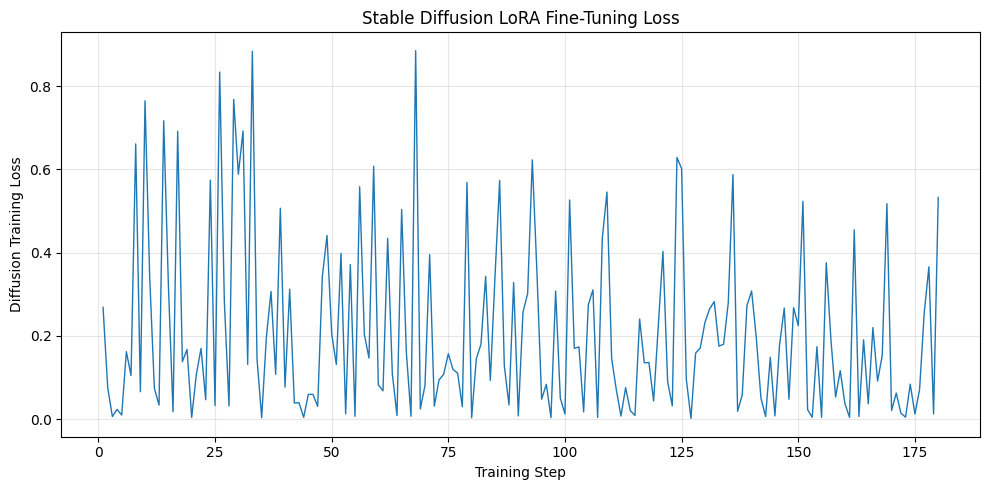


===== LOSS SUMMARY =====
Training steps: 180
Initial recorded loss: 0.268781
Final recorded loss: 0.532449
Epoch 1 average: 0.253126
Epoch 2 average: 0.194558
Epoch 3 average: 0.180900

PASS - Training loss plot saved.
Saved to: outputs/task1/training/training_loss.png


In [ ]:
# ============================================================
# SAVE AND VISUALIZE TRAINING LOSS
# ============================================================

import os
import matplotlib.pyplot as plt

print("===== TRAINING LOSS ANALYSIS =====")

os.makedirs("outputs/task1/training", exist_ok=True)

loss_plot_path = "outputs/task1/training/training_loss.png"

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(training_losses) + 1),
    training_losses,
    linewidth=1
)

plt.xlabel("Training Step")
plt.ylabel("Diffusion Training Loss")
plt.title("Stable Diffusion LoRA Fine-Tuning Loss")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(loss_plot_path, dpi=150)
plt.show()

print("\n===== LOSS SUMMARY =====")
print("Training steps:", len(training_losses))
print("Initial recorded loss:", f"{training_losses[0]:.6f}")
print("Final recorded loss:", f"{training_losses[-1]:.6f}")
print(
    "Epoch 1 average:",
    f"{sum(training_losses[:60]) / 60:.6f}"
)
print(
    "Epoch 2 average:",
    f"{sum(training_losses[60:120]) / 60:.6f}"
)
print(
    "Epoch 3 average:",
    f"{sum(training_losses[120:180]) / 60:.6f}"
)

assert len(training_losses) == 180
assert os.path.exists(loss_plot_path)

print("\nPASS - Training loss plot saved.")
print("Saved to:", loss_plot_path)

In [ ]:
# ============================================================
# SAVE TRAINED LORA WEIGHTS
# ============================================================

import os

print("===== SAVING TRAINED LORA WEIGHTS =====")

LORA_OUTPUT_DIR = "outputs/task1/lora_custom_dataset"

os.makedirs(LORA_OUTPUT_DIR, exist_ok=True)

pipeline.unet.save_lora_adapter(
    LORA_OUTPUT_DIR,
    adapter_name="custom_dataset_adapter",
    weight_name="pytorch_lora_weights.safetensors",
    safe_serialization=True
)

LORA_WEIGHT_PATH = os.path.join(
    LORA_OUTPUT_DIR,
    "pytorch_lora_weights.safetensors"
)

print("\n===== SAVE VERIFICATION =====")
print("LoRA directory:", LORA_OUTPUT_DIR)
print("LoRA weights:", LORA_WEIGHT_PATH)

assert os.path.exists(LORA_WEIGHT_PATH), \
    "LoRA weight file was not saved."

file_size_mb = os.path.getsize(LORA_WEIGHT_PATH) / (1024 ** 2)

print(f"File size: {file_size_mb:.2f} MB")

assert file_size_mb > 0

print("\nPASS - Trained LoRA weights saved successfully.")
print("PASS - SafeTensors file verified.")

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


===== SAVING TRAINED LORA WEIGHTS =====

===== SAVE VERIFICATION =====
LoRA directory: outputs/task1/lora_custom_dataset
LoRA weights: outputs/task1/lora_custom_dataset/pytorch_lora_weights.safetensors
File size: 3.08 MB

PASS - Trained LoRA weights saved successfully.
PASS - SafeTensors file verified.


In [ ]:
# ============================================================
# RELOAD SAVED LORA WEIGHTS DIRECTLY INTO A FRESH UNET
# ============================================================

print("===== RELOADING SAVED LORA WEIGHTS =====")

import torch
from safetensors.torch import load_file
from diffusers import StableDiffusionPipeline
from peft import LoraConfig, set_peft_model_state_dict

# ------------------------------------------------------------
# Load a completely fresh Stable Diffusion pipeline
# ------------------------------------------------------------

reload_pipeline = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype
).to(device)

# ------------------------------------------------------------
# Recreate the same LoRA configuration used during training
# ------------------------------------------------------------

reload_pipeline.unet.requires_grad_(False)

reload_lora_config = LoraConfig(
    r=4,
    lora_alpha=4,
    target_modules=[
        "to_q",
        "to_k",
        "to_v",
        "to_out.0"
    ],
    lora_dropout=0.0,
    bias="none"
)

reload_pipeline.unet.add_adapter(
    reload_lora_config,
    adapter_name="custom_dataset_adapter"
)

# ------------------------------------------------------------
# Load the saved SafeTensors weights
# ------------------------------------------------------------

saved_lora_state = load_file(
    LORA_WEIGHT_PATH,
    device="cpu"
)

print("Saved LoRA tensors:", len(saved_lora_state))

# ------------------------------------------------------------
# Insert saved weights into the fresh adapter
# ------------------------------------------------------------

set_peft_model_state_dict(
    reload_pipeline.unet,
    saved_lora_state,
    adapter_name="custom_dataset_adapter"
)

reload_pipeline.unet.set_adapter(
    "custom_dataset_adapter"
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

loaded_trainable_parameters = sum(
    parameter.numel()
    for parameter in reload_pipeline.unet.parameters()
    if parameter.requires_grad
)

print("\n===== RELOAD VERIFICATION =====")
print("Model:", MODEL_ID)
print("LoRA file:", LORA_WEIGHT_PATH)
print("Loaded LoRA tensors:", len(saved_lora_state))
print("Trainable adapter parameters:", loaded_trainable_parameters)
print(
    "Active adapter:",
    reload_pipeline.unet.active_adapters()
)

assert len(saved_lora_state) > 0
assert loaded_trainable_parameters > 0
assert "custom_dataset_adapter" in reload_pipeline.unet.active_adapters()

print("\nPASS - Fresh Stable Diffusion pipeline loaded.")
print("PASS - Saved LoRA SafeTensors loaded.")
print("PASS - LoRA adapter is active.")
print("PASS - Trained weights are ready for adapted image generation.")

===== RELOADING SAVED LORA WEIGHTS =====


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Saved LoRA tensors: 256

===== RELOAD VERIFICATION =====
Model: stable-diffusion-v1-5/stable-diffusion-v1-5
LoRA file: outputs/task1/lora_custom_dataset/pytorch_lora_weights.safetensors
Loaded LoRA tensors: 256
Trainable adapter parameters: 797184
Active adapter: ['custom_dataset_adapter']

PASS - Fresh Stable Diffusion pipeline loaded.
PASS - Saved LoRA SafeTensors loaded.
PASS - LoRA adapter is active.
PASS - Trained weights are ready for adapted image generation.


In [ ]:
# ============================================================
# GENERATE IMAGES WITH THE RELOADED FINE-TUNED MODEL
# ============================================================

import os
import matplotlib.pyplot as plt

print("===== GENERATING ADAPTED IMAGES =====")

ADAPTED_OUTPUT_DIR = "outputs/task1/adapted"
os.makedirs(ADAPTED_OUTPUT_DIR, exist_ok=True)

# Use the same three captions used for the baseline images
adapted_prompts = [
    "A child in a pink dress is climbing up a set of stairs in an entry way .",
    "A black dog and a spotted dog are fighting",
    "A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl ."
]

adapted_images = []

for i, prompt in enumerate(adapted_prompts, start=1):

    print(f"\nGenerating image {i}/3")
    print("Prompt:", prompt)

    generator = torch.Generator(
        device=device
    ).manual_seed(42 + i)

    result = reload_pipeline(
        prompt,
        num_inference_steps=20,
        guidance_scale=7.5,
        generator=generator
    )

    image = result.images[0]
    adapted_images.append(image)

    image_path = os.path.join(
        ADAPTED_OUTPUT_DIR,
        f"adapted_{i}.png"
    )

    image.save(image_path)

print("\n===== ADAPTED IMAGE VERIFICATION =====")

for i in range(1, 4):

    image_path = os.path.join(
        ADAPTED_OUTPUT_DIR,
        f"adapted_{i}.png"
    )

    assert os.path.exists(image_path)

    print(f"PASS - Saved: {image_path}")

print("\nPASS - Three images generated with the reloaded LoRA model.")

===== GENERATING ADAPTED IMAGES =====

Generating image 1/3
Prompt: A child in a pink dress is climbing up a set of stairs in an entry way .


  0%|          | 0/20 [00:00<?, ?it/s]


Generating image 2/3
Prompt: A black dog and a spotted dog are fighting


  0%|          | 0/20 [00:00<?, ?it/s]


Generating image 3/3
Prompt: A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .


  0%|          | 0/20 [00:00<?, ?it/s]


===== ADAPTED IMAGE VERIFICATION =====
PASS - Saved: outputs/task1/adapted/adapted_1.png
PASS - Saved: outputs/task1/adapted/adapted_2.png
PASS - Saved: outputs/task1/adapted/adapted_3.png

PASS - Three images generated with the reloaded LoRA model.


===== CREATING BASELINE VS ADAPTED COMPARISON =====
PASS - All baseline images found.
PASS - All adapted images found.


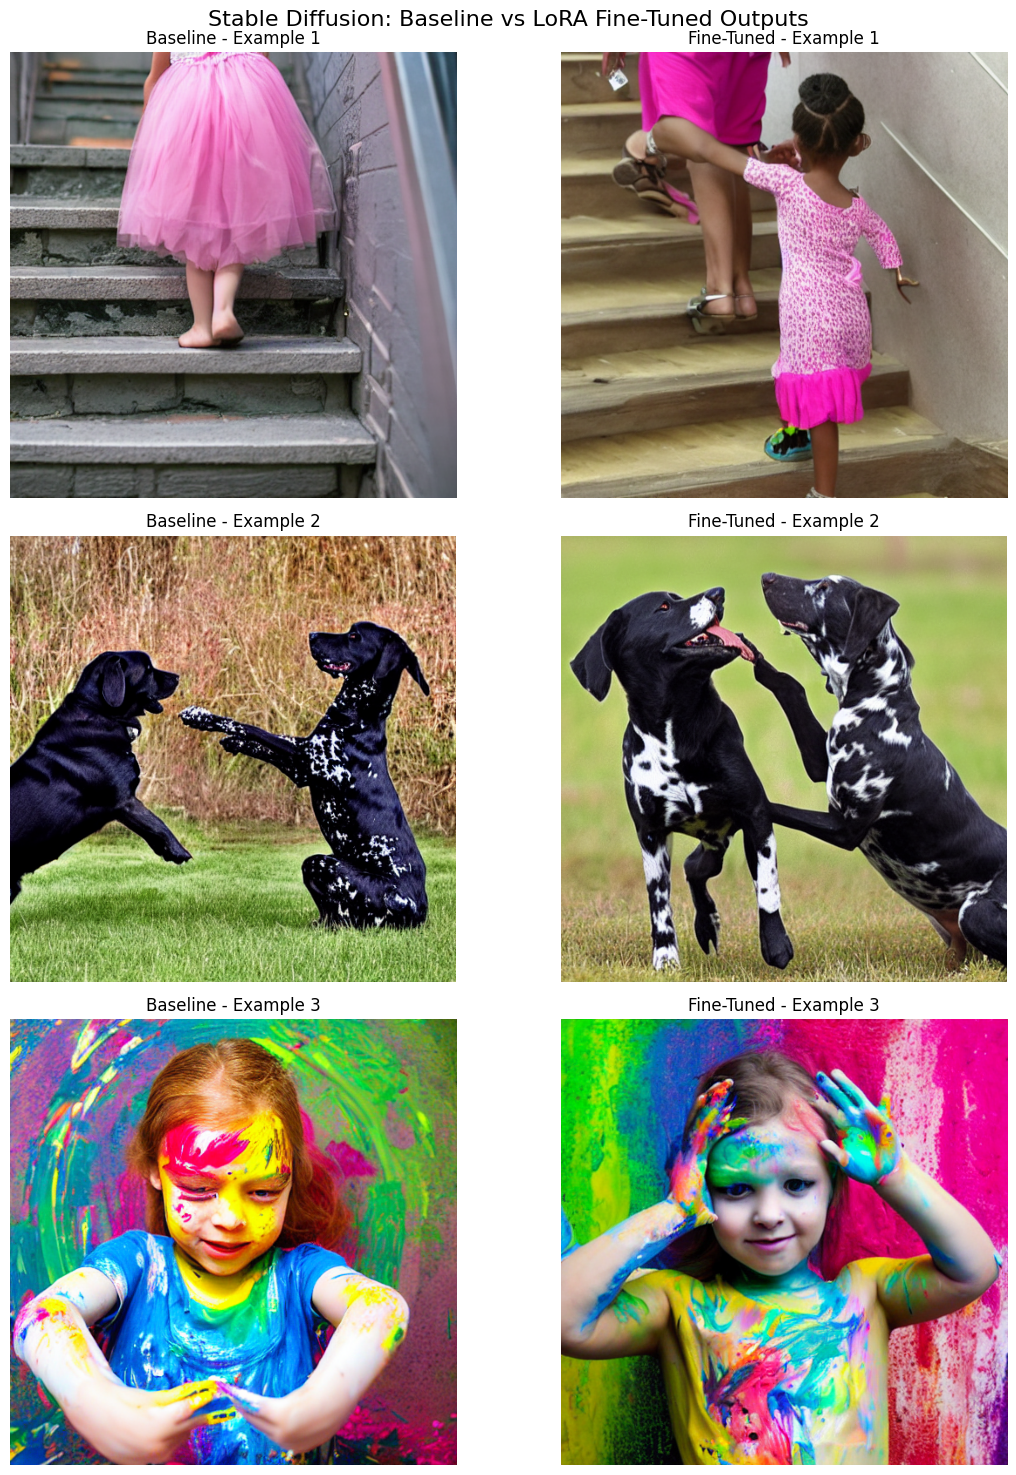


===== COMPARISON VERIFICATION =====
Comparison file: outputs/task1/comparison/baseline_vs_adapted_comparison.png

PASS - Baseline and fine-tuned outputs compared.
PASS - Comparison figure saved successfully.


In [ ]:
# ============================================================
# COMPARE BASELINE AND FINE-TUNED OUTPUTS
# ============================================================

import os
import matplotlib.pyplot as plt
from PIL import Image

print("===== CREATING BASELINE VS ADAPTED COMPARISON =====")

COMPARISON_DIR = "outputs/task1/comparison"
os.makedirs(COMPARISON_DIR, exist_ok=True)

comparison_path = os.path.join(
    COMPARISON_DIR,
    "baseline_vs_adapted_comparison.png"
)

# ------------------------------------------------------------
# Load baseline images saved before fine-tuning
# ------------------------------------------------------------

baseline_paths = [
    "outputs/task1/baseline/baseline_1.png",
    "outputs/task1/baseline/baseline_2.png",
    "outputs/task1/baseline/baseline_3.png"
]

adapted_paths = [
    "outputs/task1/adapted/adapted_1.png",
    "outputs/task1/adapted/adapted_2.png",
    "outputs/task1/adapted/adapted_3.png"
]

# ------------------------------------------------------------
# Verify all images exist
# ------------------------------------------------------------

for path in baseline_paths + adapted_paths:
    assert os.path.exists(path), f"Missing image: {path}"

print("PASS - All baseline images found.")
print("PASS - All adapted images found.")

# ------------------------------------------------------------
# Create comparison figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 15)
)

for i in range(3):

    baseline_image = Image.open(
        baseline_paths[i]
    )

    adapted_image = Image.open(
        adapted_paths[i]
    )

    axes[i, 0].imshow(baseline_image)
    axes[i, 0].set_title(
        f"Baseline - Example {i + 1}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(adapted_image)
    axes[i, 1].set_title(
        f"Fine-Tuned - Example {i + 1}"
    )
    axes[i, 1].axis("off")

fig.suptitle(
    "Stable Diffusion: Baseline vs LoRA Fine-Tuned Outputs",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    comparison_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\n===== COMPARISON VERIFICATION =====")
print("Comparison file:", comparison_path)

assert os.path.exists(comparison_path)

print("\nPASS - Baseline and fine-tuned outputs compared.")
print("PASS - Comparison figure saved successfully.")

# RESULTS AND LIMITATIONS

## Results

The pretrained Stable Diffusion v1.5 model was refined using a custom-curated subset of the Flickr8k image-caption dataset and LoRA-based parameter-efficient fine-tuning.

Key results:

- Training examples used: 60 image-caption pairs
- Fine-tuning epochs: 3
- Total optimization steps: 180
- LoRA trainable parameters: 797,184
- Total UNet parameters: 860,318,148
- Trainable parameter ratio: 0.0927%
- Epoch 1 average loss: 0.253126
- Epoch 2 average loss: 0.194558
- Epoch 3 average loss: 0.180900
- LoRA weights saved successfully as SafeTensors
- Saved LoRA weight size: approximately 3.08 MB
- Saved weights were successfully reloaded into a fresh Stable Diffusion pipeline
- Three fine-tuned images were generated successfully
- Baseline and fine-tuned outputs were compared visually

The decrease in average diffusion training loss across the three epochs shows that the LoRA parameters were successfully optimized during fine-tuning.

## Limitations

- The experiment used only 60 training image-caption pairs because of the available compute resources.
- Training was limited to 3 epochs and 180 optimization steps.
- Only one caption was used for each selected training image.
- Flickr8k is a general image-caption dataset rather than a specialized medical or artistic dataset.
- The comparison between baseline and fine-tuned outputs is qualitative; no formal image-quality or semantic-similarity metric was used.
- The experiment demonstrates the complete fine-tuning workflow and parameter adaptation, but larger datasets and longer training would be required for stronger domain adaptation.

## Conclusion

This experiment demonstrates an end-to-end workflow for refining a pretrained text-to-image model with a custom-curated image-caption dataset. The workflow includes dataset preparation, baseline generation, LoRA configuration, actual diffusion training with backpropagation and optimizer updates, loss tracking, weight saving, weight reloading, adapted image generation, and baseline-versus-fine-tuned comparison.

In [ ]:
# FINAL TASK 1 VERIFICATION

import os
import torch

print("===== FINAL TASK 1 VERIFICATION =====")

checks = {
    "Training dataset prepared": len(training_dataset) == 60,
    "Training completed": global_step == 180,
    "All losses finite": all(torch.isfinite(torch.tensor(x)) for x in training_losses),
    "Loss plot exists": os.path.exists("outputs/task1/training/training_loss.png"),
    "LoRA weights exist": os.path.exists(
        "outputs/task1/lora_custom_dataset/pytorch_lora_weights.safetensors"
    ),
    "Reloaded adapter active": "custom_dataset_adapter" in reload_pipeline.unet.active_adapters(),
    "Adapted image 1 exists": os.path.exists("outputs/task1/adapted/adapted_1.png"),
    "Adapted image 2 exists": os.path.exists("outputs/task1/adapted/adapted_2.png"),
    "Adapted image 3 exists": os.path.exists("outputs/task1/adapted/adapted_3.png"),
    "Comparison exists": os.path.exists(
        "outputs/task1/comparison/baseline_vs_adapted_comparison.png"
    ),
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} - {name}")

print("\n===== SUMMARY =====")
print(f"Passed checks: {sum(checks.values())}/{len(checks)}")

assert all(checks.values()), "One or more Task 1 verification checks failed."

print("\nPASS - TASK 1 VERIFICATION COMPLETE")

===== FINAL TASK 1 VERIFICATION =====
PASS - Training dataset prepared
PASS - Training completed
PASS - All losses finite
PASS - Loss plot exists
PASS - LoRA weights exist
PASS - Reloaded adapter active
PASS - Adapted image 1 exists
PASS - Adapted image 2 exists
PASS - Adapted image 3 exists
PASS - Comparison exists

===== SUMMARY =====
Passed checks: 10/10

PASS - TASK 1 VERIFICATION COMPLETE
